<a href="https://colab.research.google.com/github/mateosanlu/MachineLearning/blob/main/ML_Caso_Rotacion_Empleados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso de Estudio: Recursos Humanos

## Predicción de rotación de empleados

En este caso de estudio se utilizarán diferentes algoritmos de Machine Learning para predecir si un empleado podría renunciar a la empresa.

El objetivo es analizar características como la edad, el salario, la antigüedad, la satisfacción laboral y las horas extra trabajadas para identificar patrones asociados a la renuncia de empleados.

Al finalizar, se compararán varios modelos de clasificación y se seleccionará el que presente el mejor desempeño.

# Paso 1. Importación de librerías

Antes de comenzar es necesario importar las librerías que utilizaremos durante todo el proyecto.

Cada librería cumple una función específica:

- pandas: permite crear y manipular tablas de datos.
- numpy: facilita la generación de datos numéricos aleatorios.
- matplotlib y seaborn: se utilizan para crear gráficos.
- sklearn: proporciona los algoritmos de Machine Learning y herramientas de evaluación.

Estas herramientas son ampliamente utilizadas en proyectos reales de ciencia de datos.

In [2]:
import pandas as pd

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Paso 1. Construcción del Dataset

En este ejercicio se trabaja con un conjunto de datos que representa empleados de una organización.

Cada fila corresponde a un empleado y cada columna contiene información que podría influir en la decisión de permanecer o abandonar la empresa.

Las variables utilizadas son:

- edad: edad del empleado.
- salario: salario mensual.
- años_empresa: tiempo que lleva trabajando en la organización.
- satisfaccion: nivel de satisfacción laboral.
- horas_extra: carga adicional de trabajo.
- renuncia: variable objetivo.

La variable renuncia tiene dos posibles valores:

- 0 = permanece en la empresa.
- 1 = abandona la empresa.

Esta será la variable que intentarán predecir los modelos.

In [3]:
data = {
    "edad": [
        25, 28, 35, 40, 30, 45, 32, 29, 50, 38,
        27, 33, 41, 36, 31, 48, 26, 39, 42, 34
    ],
    "salario": [
        1800, 2000, 3500, 4500, 2200, 5000, 2800, 2100, 6000, 4000,
        1900, 3000, 4700, 3600, 2500, 5500, 1700, 4200, 4800, 3200
    ],
    "años_empresa": [
        1, 2, 5, 8, 2, 10, 4, 2, 15, 7,
        1, 4, 9, 6, 3, 12, 1, 8, 10, 5
    ],
    "satisfaccion": [
        2, 3, 7, 8, 3, 9, 5, 2, 9, 7,
        2, 6, 8, 6, 4, 9, 1, 7, 8, 5
    ],
    "horas_extra": [
        15, 12, 5, 4, 14, 3, 8, 13, 2, 6,
        16, 7, 4, 6, 10, 3, 18, 5, 4, 8
    ],
    "renuncia": [
        1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 0, 1, 0, 1, 0, 0, 0
    ]
}

df = pd.DataFrame(data)

print("Dataset inicial:")
print(df.head())

Dataset inicial:
   edad  salario  años_empresa  satisfaccion  horas_extra  renuncia
0    25     1800             1             2           15         1
1    28     2000             2             3           12         1
2    35     3500             5             7            5         0
3    40     4500             8             8            4         0
4    30     2200             2             3           14         1


# Paso 2. Definición de variables predictoras y objetivo

Todo modelo de Machine Learning necesita separar las variables en dos grupos.

## Variables predictoras (X)

Contienen la información que utilizará el modelo para aprender patrones.

En este caso:

- edad
- salario
- años_empresa
- satisfaccion
- horas_extra

## Variable objetivo (y)

Corresponde al resultado que se desea predecir.

En este ejercicio la variable objetivo es:

- renuncia

El propósito del entrenamiento es que el algoritmo aprenda la relación entre X e y.

In [4]:
X = df[
    [
        "edad",
        "salario",
        "años_empresa",
        "satisfaccion",
        "horas_extra"
    ]
]

y = df["renuncia"]

# Paso 3. División de los datos

Antes de entrenar los modelos es necesario separar los registros en dos grupos.

## Entrenamiento

Se utiliza para que el algoritmo aprenda patrones.

## Prueba

Se utiliza para evaluar qué tan bien funciona el modelo con información que nunca ha visto.

Parámetros utilizados:

- test_size=0.30 → 30% de los datos para pruebas.
- random_state=42 → garantiza resultados reproducibles.
- stratify=y → mantiene la misma proporción de clases en ambos conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Paso 4. Definición de modelos

No existe un algoritmo que sea el mejor para todos los problemas.

Por esta razón se probarán varios modelos de clasificación y posteriormente se compararán sus resultados.

Cada algoritmo utiliza una estrategia diferente para aprender los patrones presentes en los datos.

Los modelos seleccionados son:

- Regresión Logística
- Árbol de Decisión
- Random Forest
- KNN
- SVM
- Naive Bayes

In [6]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(kernel="linear"),
    "Naive Bayes": GaussianNB()
}

# Paso 5. Entrenamiento y evaluación

A continuación se ejecutará un ciclo que recorrerá todos los modelos definidos.

Para cada algoritmo se realizarán los siguientes pasos:

1. Entrenamiento del modelo.
2. Generación de predicciones.
3. Cálculo de métricas.
4. Validación cruzada.
5. Almacenamiento de resultados.

Esto permite comparar todos los modelos bajo las mismas condiciones.

In [7]:
resultados = []

for nombre, modelo in modelos.items():

    print("\n" + "="*70)
    print("MODELO:", nombre)
    print("="*70)

    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicción
    y_pred = modelo.predict(X_test)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Validación cruzada
    cv_scores = cross_val_score(
        modelo,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_promedio = cv_scores.mean()

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Validación cruzada": cv_promedio
    })

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Validación cruzada:", cv_scores)
    print("Promedio:", cv_promedio)



MODELO: Regresión Logística

Matriz de confusión:
[[4 0]
 [0 2]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Validación cruzada: [1. 1. 1. 1. 1.]
Promedio: 1.0

MODELO: Árbol de Decisión

Matriz de confusión:
[[4 0]
 [0 2]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Validación cruzada: [1. 1. 1. 1. 1.]
Promedio: 1.0

MODELO: Random Forest

Matriz de confusión:
[[4 0]
 [0 2]]


# Interpretación de las métricas

Durante la ejecución anterior se generan varias métricas.

## Accuracy

Mide el porcentaje total de predicciones correctas.

## Precision

Indica qué tan confiables son las predicciones positivas realizadas por el modelo.

## Recall

Mide cuántas renuncias reales fue capaz de detectar el algoritmo.

## F1-score

Combina Precision y Recall en una sola métrica.

Será la métrica principal para comparar los modelos porque proporciona una evaluación más equilibrada.

## Validación cruzada

Permite comprobar si los resultados son consistentes utilizando diferentes particiones de los datos.

# Paso 6. Construcción de la tabla comparativa

Después de evaluar todos los modelos, los resultados almacenados se convierten en un DataFrame.

Esto permite visualizar fácilmente el rendimiento de cada algoritmo y compararlos entre sí.

La tabla se ordenará utilizando el F1-score porque será el criterio utilizado para seleccionar el mejor modelo.

In [8]:
df_resultados = pd.DataFrame(resultados)

print("\n" + "="*70)
print("TABLA COMPARATIVA")
print("="*70)

print(df_resultados.sort_values(by="F1-score", ascending=False))


TABLA COMPARATIVA
                Modelo  Accuracy  Precision  Recall  F1-score  \
0  Regresión Logística  1.000000        1.0     1.0  1.000000   
1    Árbol de Decisión  1.000000        1.0     1.0  1.000000   
2        Random Forest  1.000000        1.0     1.0  1.000000   
3                  KNN  1.000000        1.0     1.0  1.000000   
4                  SVM  1.000000        1.0     1.0  1.000000   
5          Naive Bayes  0.833333        1.0     0.5  0.666667   

   Validación cruzada  
0                1.00  
1                1.00  
2                1.00  
3                1.00  
4                0.95  
5                0.95  


# Comparación de la validación cruzada

La validación cruzada evalúa qué tan estable es cada modelo cuando se entrena y evalúa utilizando diferentes particiones del conjunto de datos.

Un valor alto y consistente indica que el modelo mantiene un buen rendimiento independientemente de cómo se dividan los datos.

Esto ayuda a verificar que los resultados no dependen exclusivamente de una única partición de entrenamiento y prueba.

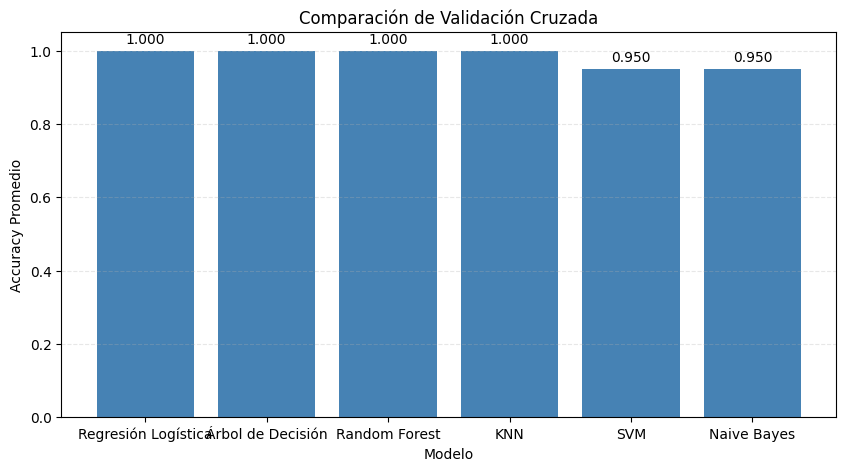

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["Validación cruzada"],
    color="steelblue"
)

plt.title("Comparación de Validación Cruzada")
plt.ylabel("Accuracy Promedio")
plt.xlabel("Modelo")

plt.ylim(0, 1.05)

for i, valor in enumerate(df_resultados["Validación cruzada"]):
    plt.text(
        i,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# Paso 7. Selección del mejor modelo

Finalmente se selecciona el modelo con el valor más alto de F1-score.

La razón de utilizar esta métrica es que considera simultáneamente la precisión y la capacidad de detectar casos positivos.

De esta forma se obtiene una visión más equilibrada del desempeño general del modelo.

In [9]:
mejor_modelo = df_resultados.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

print("\nMejor modelo según F1-score:")
print(mejor_modelo)


Mejor modelo según F1-score:
Modelo                Regresión Logística
Accuracy                              1.0
Precision                             1.0
Recall                                1.0
F1-score                              1.0
Validación cruzada                    1.0
Name: 0, dtype: object


# Interpretación de Resultados

Los resultados muestran que la mayoría de los algoritmos alcanzaron un Accuracy y un F1-score cercanos o iguales a 1.0.

Esto indica que fueron capaces de identificar correctamente los patrones presentes en el conjunto de datos.

La principal razón es que el dataset presenta una separación bastante clara entre los empleados que renuncian y aquellos que permanecen en la empresa.

En general, los empleados que renuncian presentan:

- Menor salario.
- Menor satisfacción laboral.
- Mayor cantidad de horas extra.

Mientras que los empleados que permanecen suelen presentar:

- Salarios más altos.
- Mayor satisfacción.
- Menor carga de trabajo adicional.

Estas diferencias hacen que los modelos puedan distinguir fácilmente ambas clases.

El modelo Naive Bayes obtuvo un rendimiento ligeramente inferior debido a que asume independencia entre las variables predictoras. En este caso existen relaciones entre algunas características de los empleados, por lo que otros algoritmos logran representar mejor los patrones presentes en los datos.

Aunque los resultados son muy altos, es importante considerar que el dataset contiene únicamente 20 registros. Debido a este tamaño reducido, los valores obtenidos pueden ser optimistas y no garantizan que el desempeño sea igual de bueno en un conjunto de datos real.

Finalmente, la validación cruzada mostró resultados consistentes para casi todos los modelos, lo que indica que el comportamiento observado se mantiene relativamente estable al utilizar diferentes particiones del conjunto de datos.

Según el criterio de F1-score, el mejor modelo corresponde a aquel que logró el mejor equilibrio entre precisión y capacidad de detección de empleados con riesgo de renuncia.

Una limitación importante del estudio es el tamaño reducido del conjunto de datos. En escenarios reales sería recomendable utilizar cientos o miles de registros, incorporar más variables relacionadas con el desempeño laboral y utilizar técnicas adicionales de validación para obtener conclusiones más robustas.